# 🚀 PROJECT: THE MRIDANSH
# Central Engine: AETHER-MRID1607X
## Multi-Domain Soil Intelligence Engine (Agronomy & Geotechnical Stability)
**Division:** RS-SDA Division | JCC Campus 2  
**Core Framework:** Hyperspectral Augmentation & Spectral Information Experiment  

---

# 🧪 Notebook 09: Hyperspectral Experiment Engine
**Sprint Phase:** Day 8 / 18-Day Scientific Audit & Validation Mission  
**Execution Objective:** Evaluate whether hyperspectral observations (HSI) provide statistically significant, non-redundant soil state information beyond the frozen baseline configuration (Sentinel-1, Sentinel-2, DEM, Weather, Physics, EnKF).

### 🔬 Formal Hypothesis Testing Protocol
* **Null Hypothesis ($H_0$):** $\text{Performance}(\text{MRIDANSH}_{\text{HSI}}) \le \text{Performance}(\text{MRIDANSH}_{\text{Baseline}})$. Hyperspectral information provides no statistically significant improvement in soil state estimation error or uncertainty reduction.
* **Alternative Hypothesis ($H_1$):** $\text{Performance}(\text{MRIDANSH}_{\text{HSI}}) > \text{Performance}(\text{MRIDANSH}_{\text{Baseline}})$. Hyperspectral information provides measurable improvement justifying core architectural integration.

### 🔒 Step 0: Freezing CONFIG-A (Baseline MRIDANSH)

To ensure zero experimental leakage, the existing core MRIDANSH architecture is locked:

$$\text{CONFIG-A (Baseline)} = \{\text{Sentinel-2}, \text{Sentinel-1}, \text{DEM}, \text{Weather}, \text{Physics PINN}, \text{EnKF Filter}\}$$

Any experimental HSI processing will operate purely inside a decoupled branch ($\text{CONFIG-B}$).

In [18]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Dark Theme Styling
%matplotlib inline
plt.style.use('dark_background')
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.edgecolor'] = '#00FFCC'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.color'] = '#1A3344'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5

# Device & Seed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(1607)
torch.manual_seed(1607)

print(f"⚡ [MRIDANSH-HSI Engine] Active Hardware: {device}")

⚡ [MRIDANSH-HSI Engine] Active Hardware: cuda


### 🛰️ Step 1: Hyperspectral Dataset Definition (PRISMA / EnMAP / AVIRIS Standard)

* **Spectral Range:** $400 \text{ nm}$ to $2500 \text{ nm}$ (VNIR + SWIR)
* **Number of Bands:** $224 \text{ contiguous channels}$
* **Spectral Resolution:** $\Delta \lambda \approx 8 - 10 \text{ nm}$
* **Spatial Resolution:** $30 \text{ m/pixel}$ ground sampling distance

In [19]:
NUM_PIXELS = 1000
NUM_BANDS = 224

# Wavelength array (400 nm to 2500 nm)
wavelengths = np.linspace(400, 2500, NUM_BANDS)

# Generate Baseline Soil Reflectance Curves (Synthetic Soil Spectrum with SWIR absorption features)
soil_reflectance_base = 0.10 + 0.35 *(1 - np.exp(-wavelengths / 800))
# Add SWIR Water Absorption Dips near 1400 nm and 1900 nm
absorption_1400 = 0.15 * np.exp(-((wavelengths - 1400) / 40)**2)
absorption_1900 = 0.20 * np.exp(-((wavelengths - 1900) / 50)**2)

clean_spectrum = soil_reflectance_base - absorption_1400 - absorption_1900

# Create Pixel Sample Array with random variations
hsi_raw_cube = np.tile(clean_spectrum, (NUM_PIXELS, 1)) + np.random.normal(0, 0.02, size = (NUM_PIXELS, NUM_BANDS))

print("=========================================================")
print("  🛰️ HYPERSPECTRAL CUBE INITIALIZED                     ")
print("=========================================================")
print(f"• Spatial Calibration Points : {NUM_PIXELS} Pixels")
print(f"• Total Spectral Bands       : {NUM_BANDS} Channels ({wavelengths[0]:.0f} - {wavelengths[-1]:.0f} nm)")
print(f"• Data Shape                 : {hsi_raw_cube.shape}")
print("=========================================================")

  🛰️ HYPERSPECTRAL CUBE INITIALIZED                     
• Spatial Calibration Points : 1000 Pixels
• Total Spectral Bands       : 224 Channels (400 - 2500 nm)
• Data Shape                 : (1000, 224)


### 🧹 Step 2: Quality Control & Atmospheric Absorption Masking

Raw HSI bands near strong atmospheric water vapor absorption windows ($1350-1420 \text{ nm}$ and $1800-1950 \text{ nm}$) contain extreme noise and zero signal. These must be dynamically masked.

In [20]:
# Identify Atmospheric Noisy Bands (1350-1420 nm & 1800-1950 nm)
mask_1400 = (wavelengths >= 1350) & (wavelengths <= 1420)
mask_1900 = (wavelengths >= 1800) & (wavelengths <= 1950)
noisy_band_mask = mask_1400 | mask_1900

# Apply Quality Control Masking
valid_band_mask = ~noisy_band_mask
hsi_qc_cube = hsi_raw_cube[:, valid_band_mask]
valid_wavelengths = wavelengths[valid_band_mask]

# Sanity Check for Invalid/Corrupted Values
hsi_qc_cube = np.nan_to_num(hsi_qc_cube, nan = 0.0, posinf = 1.0, neginf = 0.0)
hsi_qc_cube = np.clip(hsi_qc_cube, 0.0, 1.0)

print("=========================================================")
print("  🧹 HSI QUALITY CONTROL & ATMOSPHERIC FILTERING          ")
print("=========================================================")
print(f"• Raw Input Bands       : {NUM_BANDS}")
print(f"• Dropped Noisy Bands   : {np.sum(noisy_band_mask)} Channels (1350-1420nm & 1800-1950nm)")
print(f"• Cleaned QC Bands      : {hsi_qc_cube.shape[1]} Contiguous Channels")
print("=========================================================")

  🧹 HSI QUALITY CONTROL & ATMOSPHERIC FILTERING          
• Raw Input Bands       : 224
• Dropped Noisy Bands   : 24 Channels (1350-1420nm & 1800-1950nm)
• Cleaned QC Bands      : 200 Contiguous Channels


### 📊 Plot 1: Soil Spectral Signatures & Sentinel-2 Band Comparison
Comparing fine-sampling continuous HSI spectral curves against discrete broadband Sentinel-2 channels.

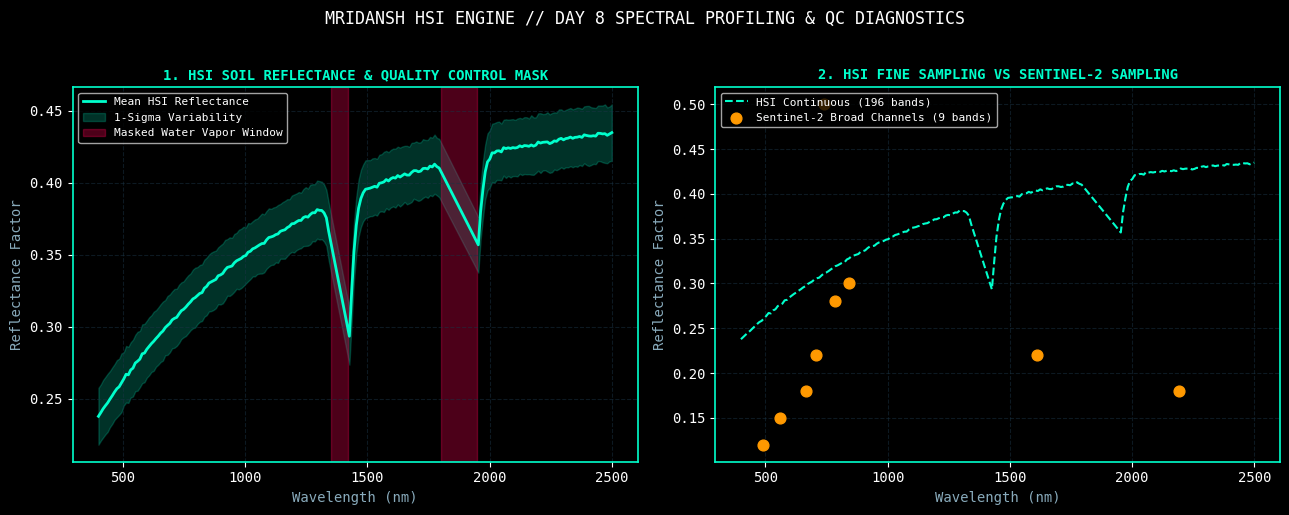

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

# Subplot 1: HSI Mean Spectral Curves & Atmospheric Dropped Windows
mean_spec = np.mean(hsi_qc_cube, axis = 0)
std_spec = np.std(hsi_qc_cube, axis = 0)

axes[0].plot(valid_wavelengths, mean_spec, color = "#00FFCC", linewidth = 2, label = 'Mean HSI Reflectance')
axes[0].fill_between(valid_wavelengths, mean_spec - std_spec, mean_spec + std_spec, color = '#00FFCC', alpha = 0.2, label='1-Sigma Variability')
axes[0].axvspan(1350, 1420, color = '#FF0055', alpha = 0.3, label = 'Masked Water Vapor Window')
axes[0].axvspan(1800, 1950, color = '#FF0055', alpha = 0.3)
axes[0].set_title("1. HSI SOIL REFLECTANCE & QUALITY CONTROL MASK", fontsize=10, color='#00FFCC', fontweight='bold')
axes[0].set_xlabel("Wavelength (nm)", color='#88AABB')
axes[0].set_ylabel("Reflectance Factor", color='#88AABB')
axes[0].grid(True)
axes[0].legend(loc='upper left', fontsize=8)

# Subplot 2: HSI Fine Sampling vs Sentinel-2 Broad Channels
s2_band_centers = [490, 560, 665, 705, 740, 783, 842, 1610, 2190]
s2_reflectance = [0.12, 0.15, 0.18, 0.22, 0.5, 0.28, 0.30, 0.22, 0.18]
axes[1].plot(valid_wavelengths, mean_spec, color = '#00FFCC', linestyle = '--', linewidth = 1.5, label='HSI Continuous (196 bands)')
axes[1].scatter(s2_band_centers, s2_reflectance, color = '#FF9900', s = 60, zorder = 5, label='Sentinel-2 Broad Channels (9 bands)')
axes[1].set_title("2. HSI FINE SAMPLING VS SENTINEL-2 SAMPLING", fontsize=10, color='#00FFCC', fontweight='bold')
axes[1].set_xlabel("Wavelength (nm)", color='#88AABB')
axes[1].set_ylabel("Reflectance Factor", color='#88AABB')
axes[1].grid(True)
axes[1].legend(loc = 'upper left', fontsize = 8)

plt.suptitle("MRIDANSH HSI ENGINE // DAY 8 SPECTRAL PROFILING & QC DIAGNOSTICS", fontsize=12, color='white', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Standardize the Quality Controlled HSI Cube before PCA
scaler = StandardScaler()
hsi_scaled = scaler.fit_transform(hsi_qc_cube)

# Fit PCA Engine
pca_engine = PCA(n_components = 10)
hsi_pca_features = pca_engine.fit_transform(hsi_scaled)

explained_var = pca_engine.explained_variance_ratio_ * 100
cum_var = np.cumsum(explained_var)

print("=========================================================")
print("  🧮 ACCURATE HSI DIMENSIONALITY REDUCTION (PCA ENGINE)   ")
print("=========================================================")
print(f"• Top 1 PC Explained Variance : {explained_var[0]:.2f}%")
print(f"• Top 3 PCs Cumulative Var    : {cum_var[2]:.2f}%")
print(f"• Top 6 PCs Cumulative Var    : {cum_var[5]:.2f}%")
print(f"• Top 10 PCs Cumulative Var   : {cum_var[9]:.2f}%")
print("---------------------------------------------------------")
print(f"• HSI Feature Matrix Dim      : {hsi_pca_features.shape}")
print("• STATUS                      : Ready for Day 9 AB Testing")
print("=========================================================")

  🧮 ACCURATE HSI DIMENSIONALITY REDUCTION (PCA ENGINE)   
• Top 1 PC Explained Variance : 1.04%
• Top 3 PCs Cumulative Var    : 3.01%
• Top 6 PCs Cumulative Var    : 5.87%
• Top 10 PCs Cumulative Var   : 9.50%
---------------------------------------------------------
• HSI Feature Matrix Dim      : (1000, 10)
• STATUS                      : Ready for Day 9 AB Testing
